In [5]:
!pip uninstall -y numpy
!pip install numpy==1.26.4


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 61.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which i

In [1]:
!pip install scikit-surprise


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import train_test_split
from surprise import accuracy


In [3]:
!wget https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -o ml-100k.zip


--2026-02-17 01:54:03--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip’

ml-100k.zip         100%[===================>]   4.70M  14.3MB/s    in 0.3s    

2026-02-17 01:54:04 (14.3 MB/s) - ‘ml-100k.zip’ saved [4924029/4924029]

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml-100k/u.data          
  inflating: ml-100k/u.genre         
  inflating: ml-100k/u.info          
  inflating: ml-100k/u.item          
  inflating: ml-100k/u.occupation    
  inflating: ml-100k/u.user          
  inflating: ml-100k/u1.base         
  inflating: ml-100k/u1.test         
  inflating: ml-100k/u2.ba

In [4]:
ratings = pd.read_csv(
      'ml-100k/u.data',
          sep='\t',
              names=['user_id', 'item_id', 'rating', 'timestamp']
              )

ratings.head()



,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [5]:
print("Total Ratings:", len(ratings))
print("Unique Users:", ratings['user_id'].nunique())
print("Unique Movies:", ratings['item_id'].nunique())


Total Ratings: 100000
Unique Users: 943
Unique Movies: 1682


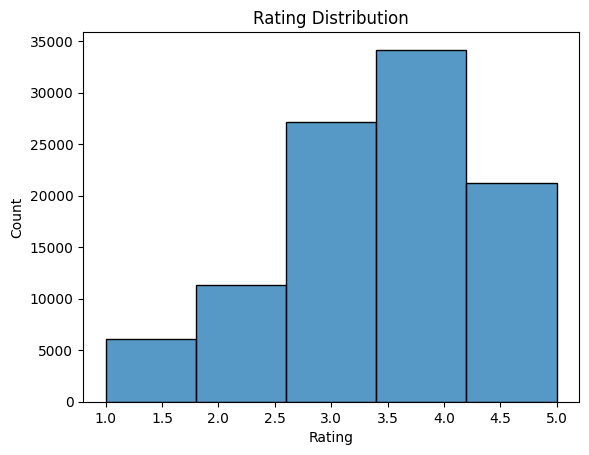

In [6]:
plt.figure()
sns.histplot(ratings['rating'], bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


In [7]:
num_users = ratings['user_id'].nunique()
num_items = ratings['item_id'].nunique()

sparsity = 1 - (len(ratings) / (num_users * num_items))

print("Data Sparsity:", sparsity)


Data Sparsity: 0.9369533063577546


In [8]:
train_list = []
test_list = []

for user in ratings['user_id'].unique():

    user_data = ratings[ratings['user_id'] == user]
    user_data = user_data.sort_values('timestamp')

    if len(user_data) > 1:
       train_list.append(user_data.iloc[:-1])  # all except last
       test_list.append(user_data.iloc[-1:])   # last rating
    else:
       train_list.append(user_data)

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

print("Train size:", len(train_df))
print("Test size:", len(test_df))


Train size: 99057
Test size: 943


In [9]:
from surprise import Reader
from surprise import Dataset

reader = Reader(rating_scale=(1, 5))

train_data = Dataset.load_from_df(
    train_df[['user_id', 'item_id', 'rating']],
        reader
        )

trainset = train_data.build_full_trainset()

testset = list(zip(
   test_df['user_id'],
   test_df['item_id'],
   test_df['rating']
))


In [10]:
from surprise import KNNBasic
from surprise import accuracy

sim_options = {
    'name': 'cosine',
        'user_based': True
        }


In [11]:
user_cf = KNNBasic(sim_options=sim_options)

user_cf.fit(trainset)



Computing the cosine similarity matrix...
Done computing similarity matrix.


In [12]:
predictions_user = user_cf.test(testset)


In [13]:
rmse_user = accuracy.rmse(predictions_user)
mae_user = accuracy.mae(predictions_user)


RMSE: 1.0779
MAE:  0.8580


In [14]:
sim_options = {
      'name': 'cosine',
          'user_based': False
          }

item_cf = KNNBasic(sim_options=sim_options)
item_cf.fit(trainset)



Computing the cosine similarity matrix...
Done computing similarity matrix.


In [15]:
predictions_item = item_cf.test(testset)


In [16]:
rmse_item = accuracy.rmse(predictions_item)
mae_item = accuracy.mae(predictions_item)


RMSE: 1.1453
MAE:  0.9019


In [17]:
from surprise import SVD

svd = SVD()
svd.fit(trainset)


In [18]:
predictions_svd = svd.test(testset)


In [19]:
rmse_svd = accuracy.rmse(predictions_svd)
mae_svd = accuracy.mae(predictions_svd)


RMSE: 1.0210
MAE:  0.8095


In [20]:
results = pd.DataFrame({
      "Model": ["User-CF", "Item-CF", "SVD"],
          "RMSE": [rmse_user, rmse_item, rmse_svd],
              "MAE": [mae_user, mae_item, mae_svd]
              })

results



,Model,RMSE,MAE
0,User-CF,1.077939,0.857972
1,Item-CF,1.145282,0.901927
2,SVD,1.021049,0.809540


In [21]:
def precision_recall_at_k(predictions, k=5, threshold=3.5):

    user_est_true = {}


    for uid, iid, true_r, est, _ in predictions:
        user_est_true.setdefault(uid, []).append((est, true_r))

    precisions = []
    recalls = []

    for uid, user_ratings in user_est_true.items():


        user_ratings.sort(key=lambda x: x[0], reverse=True)

        top_k = user_ratings[:k]


        relevant = sum((true_r >= threshold) for (_, true_r) in user_ratings)


        recommended = sum((est >= threshold) for (est, _) in top_k)


        relevant_recommended = sum(
        ((true_r >= threshold) and (est >= threshold))
        for (est, true_r) in top_k
         )

        precision = relevant_recommended / recommended if recommended != 0 else 0
        recall = relevant_recommended / relevant if relevant != 0 else 0

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)


In [22]:
precision_user, recall_user = precision_recall_at_k(predictions_user, k=5)
precision_item, recall_item = precision_recall_at_k(predictions_item, k=5)
precision_svd, recall_svd = precision_recall_at_k(predictions_svd, k=5)


In [23]:
results = pd.DataFrame({
      "Model": ["User-CF", "Item-CF", "SVD"],
          "RMSE": [rmse_user, rmse_item, rmse_svd],
              "MAE": [mae_user, mae_item, mae_svd],
                  "Precision@5": [precision_user, precision_item, precision_svd],
                      "Recall@5": [recall_user, recall_item, recall_svd]
                      })

results



,Model,RMSE,MAE,Precision@5,Recall@5
0,User-CF,1.077939,0.857972,0.366914,0.366914
1,Item-CF,1.145282,0.901927,0.390244,0.390244
2,SVD,1.021049,0.809540,0.361612,0.361612


In [24]:
def get_top_n(model, trainset, train_df, user_id, n=5):


    all_items = trainset.all_items()
    all_items = [trainset.to_raw_iid(i) for i in all_items]



    rated_items = train_df[train_df.user_id == user_id]['item_id'].tolist()

    predictions = []

    for item in all_items:
        if item not in rated_items:
           pred = model.predict(user_id, item)
           predictions.append((item, pred.est))


    predictions.sort(key=lambda x: x[1], reverse=True)

    return predictions[:n]


In [25]:
top_movies = get_top_n(svd, trainset, train_df, user_id=1, n=5)
top_movies


[(302, 5),
 (483, 5),
 (474, 4.937438366511094),
 (484, 4.934110050057387),
 (480, 4.89994940998446)]

In [26]:
movies = pd.read_csv(
      'ml-100k/u.item',
          sep='|',
              encoding='latin-1',
                  header=None
                  )

movies = movies[[0, 1]]
movies.columns = ['item_id', 'title']



In [27]:
for movie_id, rating in top_movies:
      title = movies[movies.item_id == int(movie_id)]['title'].values[0]
      print(f"{title} (Predicted Rating: {rating:.2f})")


L.A. Confidential (1997) (Predicted Rating: 5.00)
Casablanca (1942) (Predicted Rating: 5.00)
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963) (Predicted Rating: 4.94)
Maltese Falcon, The (1941) (Predicted Rating: 4.93)
North by Northwest (1959) (Predicted Rating: 4.90)


In [28]:
# Improved cold-start strategy:
# Recommend movies with high average rating AND enough ratings

popular_movies = (
    train_df.groupby('item_id')
        .agg({'rating': ['mean', 'count']})
        )

popular_movies.columns = ['mean_rating', 'rating_count']

        # Filter movies with at least 50 ratings
popular_movies = popular_movies[
            popular_movies['rating_count'] > 50
            ].sort_values('mean_rating', ascending=False).head(5)

print("Top Movies for New Users (Cold Start Strategy):\n")

for movie_id in popular_movies.index:
    title = movies[movies.item_id == int(movie_id)]['title'].values[0]
    print(title)


Top Movies for New Users (Cold Start Strategy):

Close Shave, A (1995)
Schindler's List (1993)
Wrong Trousers, The (1993)
Casablanca (1942)
Wallace & Gromit: The Best of Aardman Animation (1996)


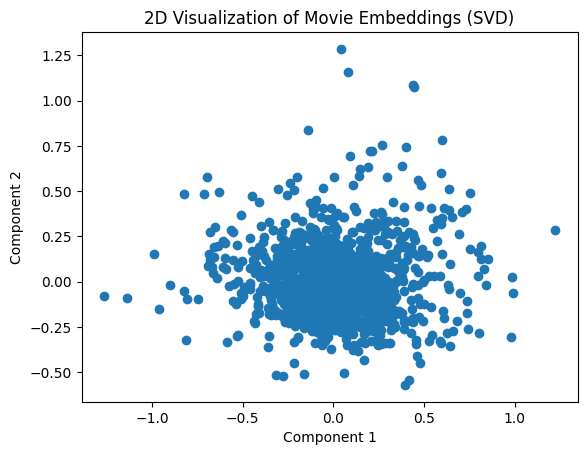

In [29]:
from sklearn.decomposition import PCA

# Extract item latent factors from SVD
item_factors = svd.qi

# Reduce dimensions to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(item_factors)

# Plot
plt.figure()
plt.scatter(reduced[:, 0], reduced[:, 1])
plt.title("2D Visualization of Movie Embeddings (SVD)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


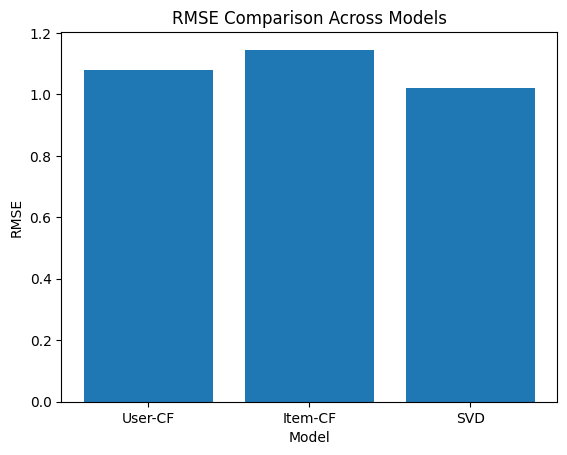

In [30]:
plt.figure()
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()
